# 03 — Thực nghiệm mô hình Regression

Mỗi mô hình phải vượt hai mốc: baseline thống kê và baseline policy `70% × số tiền yêu cầu`. Validation dùng để chọn mô hình; test nội bộ chỉ mở một lần sau khi đã chọn.

In [1]:
from pathlib import Path
import os, sys, json, warnings

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ["MPLCONFIGDIR"] = str(ROOT / ".matplotlib")
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

TRAIN_PATH = ROOT / "data" / "train.csv"
TEST_PATH = ROOT / "data" / "test.csv"
TARGET = "Loan Sanction Amount (USD)"
REQUEST = "Loan Amount Request (USD)"
RANDOM_STATE = 42

df_raw = pd.read_csv(TRAIN_PATH)
df_external = pd.read_csv(TEST_PATH)
print(f"Train: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
print(f"Test ngoài: {df_external.shape[0]:,} dòng x {df_external.shape[1]} cột")

Train: 30,000 dòng x 24 cột
Test ngoài: 20,000 dòng x 23 cột


In [2]:
SENTINEL = -999
DROP_COLUMNS = ["Customer ID", "Name", "Property ID", "Gender"]
BASE_FEATURES = [
    "Age", "Income (USD)", "Income Stability", "Profession",
    "Type of Employment", "Location", REQUEST,
    "Current Loan Expenses (USD)", "Expense Type 1", "Expense Type 2",
    "Dependents", "Credit Score", "No. of Defaults",
    "Has Active Credit Card", "Property Age", "Property Type",
    "Property Location", "Co-Applicant", "Property Price",
]
ENGINEERED_FEATURES = [
    "RequestToIncome", "RequestToProperty", "ExpenseToIncome",
    "IncomePerDependent", "PropertyEquityProxy", "CreditIncomeInteraction",
    "CreditRequestInteraction", "AgeIncomeInteraction",
]

def normalize_missing(df):
    out = df.copy()
    out = out.replace(SENTINEL, np.nan)
    return out

def add_business_features(df):
    out = normalize_missing(df)
    eps = 1e-6
    income = out["Income (USD)"].clip(lower=eps)
    request = out[REQUEST].clip(lower=0)
    property_price = out["Property Price"].clip(lower=eps)
    expenses = out["Current Loan Expenses (USD)"].clip(lower=0)
    dependents = out["Dependents"].clip(lower=0).fillna(0)
    credit = out["Credit Score"]

    out["RequestToIncome"] = request / income
    out["RequestToProperty"] = request / property_price
    out["ExpenseToIncome"] = expenses / income
    out["IncomePerDependent"] = income / (dependents + 1)
    out["PropertyEquityProxy"] = property_price - request
    out["CreditIncomeInteraction"] = credit * np.log1p(income)
    out["CreditRequestInteraction"] = credit / (request + 1) * 1000
    out["AgeIncomeInteraction"] = out["Age"] * np.log1p(income)
    return out

def modeling_frame(df):
    out = add_business_features(df)
    columns = [c for c in BASE_FEATURES + ENGINEERED_FEATURES if c in out.columns]
    return out[columns].copy()

def valid_regression_rows(df):
    target = pd.to_numeric(df[TARGET], errors="coerce")
    return target.notna() & (target > 0)

In [3]:
from sklearn.model_selection import train_test_split

def quantile_labels(y, q=10):
    return pd.qcut(y.rank(method="first"), q=q, labels=False, duplicates="drop")

def make_splits(df, random_state=RANDOM_STATE):
    clean = normalize_missing(df.loc[valid_regression_rows(df)].copy())
    train_val, test = train_test_split(
        clean,
        test_size=0.15,
        random_state=random_state,
        stratify=quantile_labels(clean[TARGET]),
    )
    train, val = train_test_split(
        train_val,
        test_size=0.1764705882,
        random_state=random_state,
        stratify=quantile_labels(train_val[TARGET]),
    )
    return train.copy(), val.copy(), test.copy()

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_squared_log_error,
)

def build_preprocessor(X, scale_numeric=False):
    numeric = X.select_dtypes(include=np.number).columns.tolist()
    categorical = X.select_dtypes(exclude=np.number).columns.tolist()
    numeric_steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale_numeric:
        numeric_steps.append(("scaler", RobustScaler()))
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(numeric_steps), numeric),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]),
                categorical,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return preprocessor

def regression_metrics(y_true, y_pred, requested=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_error = np.abs(y_true - y_pred)
    denom = np.maximum(np.abs(y_true), 1.0)
    result = {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
        "rmsle": np.sqrt(mean_squared_log_error(np.maximum(y_true, 0), np.maximum(y_pred, 0))),
        "wape": abs_error.sum() / np.abs(y_true).sum(),
        "within_10pct": np.mean(abs_error / denom <= 0.10),
        "within_20pct": np.mean(abs_error / denom <= 0.20),
        "mean_signed_error": np.mean(y_pred - y_true),
        "over_rate": np.mean(y_pred > y_true),
    }
    if requested is not None:
        requested = np.asarray(requested, dtype=float)
        result["above_request_rate"] = np.mean(y_pred > requested)
    return result

def apply_policy(raw_prediction, requested, property_price=None, max_ltv=0.90):
    prediction = np.maximum(np.asarray(raw_prediction, dtype=float), 0)
    prediction = np.minimum(prediction, np.asarray(requested, dtype=float))
    if property_price is not None:
        valid_property = np.asarray(property_price, dtype=float)
        cap = np.where(np.isfinite(valid_property) & (valid_property > 0), valid_property * max_ltv, np.inf)
        prediction = np.minimum(prediction, cap)
    return prediction

## 1. Chuẩn bị split cố định

In [5]:
train_df, val_df, test_df = make_splits(df_raw)
X_train, X_val, X_test = map(modeling_frame, [train_df, val_df, test_df])
y_train, y_val, y_test = train_df[TARGET], val_df[TARGET], test_df[TARGET]
print(X_train.shape, X_val.shape, X_test.shape)

(15019, 27) (3219, 27) (3219, 27)


## 2. Baseline thống kê và policy

In [6]:
from sklearn.dummy import DummyRegressor

results = []
fitted = {}

dummy = DummyRegressor(strategy="median").fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)
results.append({"model": "DummyMedian", **regression_metrics(y_val, dummy_pred, val_df[REQUEST])})

rule70_pred = 0.70 * val_df[REQUEST].to_numpy()
results.append({"model": "Rule70Percent", **regression_metrics(y_val, rule70_pred, val_df[REQUEST])})
display(pd.DataFrame(results).set_index("model"))

,mae,rmse,r2,rmsle,wape,within_10pct,within_20pct,mean_signed_error,over_rate,above_request_rate
model,,,,,,,,,,
DummyMedian,"33,971.556","46,068.600",-0.056,0.729,0.516,0.114,0.219,"-10,613.972",0.500,0.337
Rule70Percent,"3,756.883","6,429.580",0.979,0.076,0.057,0.820,0.995,"-1,780.738",0.418,0.000


## 3. Huấn luyện các họ mô hình

In [7]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

model_specs = {
    "Ridge": (Ridge(alpha=10.0), True),
    "RandomForest": (RandomForestRegressor(
        n_estimators=260, max_depth=18, min_samples_leaf=3,
        max_features=0.8, n_jobs=-1, random_state=RANDOM_STATE,
    ), False),
    "HistGradientBoosting": (HistGradientBoostingRegressor(
        learning_rate=0.06, max_iter=350, max_leaf_nodes=31,
        l2_regularization=1.0, random_state=RANDOM_STATE,
    ), False),
    "XGBoost": (XGBRegressor(
        n_estimators=500, max_depth=5, learning_rate=0.04,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=2.0,
        objective="reg:squarederror", n_jobs=-1, random_state=RANDOM_STATE,
    ), False),
    "LightGBM": (LGBMRegressor(
        n_estimators=500, learning_rate=0.04, num_leaves=31,
        max_depth=-1, subsample=0.85, colsample_bytree=0.85,
        reg_lambda=2.0, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    ), False),
}

for name, (estimator, scale_numeric) in model_specs.items():
    started = time.perf_counter()
    pipeline = Pipeline([
        ("preprocessor", build_preprocessor(X_train, scale_numeric=scale_numeric)),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    raw_pred = pipeline.predict(X_val)
    policy_pred = apply_policy(raw_pred, val_df[REQUEST], val_df["Property Price"])
    row = {
        "model": name,
        **regression_metrics(y_val, policy_pred, val_df[REQUEST]),
        "fit_seconds": time.perf_counter() - started,
        "raw_negative_rate": np.mean(raw_pred < 0),
    }
    results.append(row)
    fitted[name] = pipeline
    print(f"{name}: MAE={row['mae']:,.2f}, R2={row['r2']:.4f}, thời gian={row['fit_seconds']:.1f}s")

comparison = pd.DataFrame(results).sort_values("mae").reset_index(drop=True)
display(comparison)

Ridge: MAE=3,661.87, R2=0.9865, thời gian=0.1s


RandomForest: MAE=3,069.81, R2=0.9897, thời gian=8.3s


HistGradientBoosting: MAE=3,079.30, R2=0.9893, thời gian=0.5s


XGBoost: MAE=3,047.66, R2=0.9895, thời gian=1.2s


LightGBM: MAE=3,102.12, R2=0.9888, thời gian=0.6s


,model,mae,rmse,r2,rmsle,wape,within_10pct,within_20pct,mean_signed_error,over_rate,above_request_rate,fit_seconds,raw_negative_rate
0,XGBoost,"3,047.656","4,596.055",0.989,0.054,0.046,0.963,0.997,62.158,0.516,0.000,1.228,0.000
1,RandomForest,"3,069.808","4,557.460",0.990,0.054,0.047,0.966,0.998,74.847,0.511,0.000,8.276,0.000
2,HistGradientBoosting,"3,079.299","4,644.444",0.989,0.058,0.047,0.952,0.993,108.842,0.532,0.000,0.521,0.000
3,LightGBM,"3,102.115","4,746.200",0.989,0.055,0.047,0.964,0.996,75.261,0.518,0.000,0.577,0.000
4,Ridge,"3,661.870","5,203.386",0.987,0.185,0.056,0.824,0.958,67.377,0.507,0.000,0.091,0.000
5,Rule70Percent,"3,756.883","6,429.580",0.979,0.076,0.057,0.820,0.995,"-1,780.738",0.418,0.000,NaN,NaN
6,DummyMedian,"33,971.556","46,068.600",-0.056,0.729,0.516,0.114,0.219,"-10,613.972",0.500,0.337,NaN,NaN


## 4. Cross-validation cho các ứng viên tốt nhất

In [8]:
from sklearn.model_selection import KFold, cross_val_score

candidate_names = comparison[comparison["model"].isin(fitted)].head(3)["model"].tolist()
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name in candidate_names:
    scores = -cross_val_score(
        fitted[name], X_train, y_train,
        scoring="neg_mean_absolute_error", cv=cv, n_jobs=1,
    )
    cv_rows.append({
        "model": name,
        "cv_mae_mean": scores.mean(),
        "cv_mae_std": scores.std(),
        "folds": scores.tolist(),
    })
    print(f"{name}: CV MAE={scores.mean():,.2f} ± {scores.std():,.2f}")
cv_table = pd.DataFrame(cv_rows).sort_values("cv_mae_mean")
display(cv_table)

XGBoost: CV MAE=3,142.96 ± 38.31


RandomForest: CV MAE=3,100.37 ± 36.62


HistGradientBoosting: CV MAE=3,134.01 ± 48.79


,model,cv_mae_mean,cv_mae_std,folds
1,RandomForest,"3,100.375",36.620,"[3110.355949602009, 3139.3938968149278, 3051.3..."
2,HistGradientBoosting,"3,134.007",48.787,"[3116.6083425007296, 3200.5276316147, 3084.885..."
0,XGBoost,"3,142.960",38.311,"[3134.1877562272193, 3193.6480514788504, 3101...."


## 5. Chọn mô hình bằng cross-validation và mở test đúng một lần

In [9]:
best_name = cv_table.iloc[0]["model"]
print(f"Mô hình được chọn theo CV MAE trước khi mở test: {best_name}")

train_val_df = pd.concat([train_df, val_df]).sort_index()
X_train_val = modeling_frame(train_val_df)
y_train_val = train_val_df[TARGET]
best_estimator, scale_numeric = model_specs[best_name]
from sklearn.base import clone
final_pipeline = Pipeline([
    ("preprocessor", build_preprocessor(X_train_val, scale_numeric=scale_numeric)),
    ("model", clone(best_estimator)),
])
final_pipeline.fit(X_train_val, y_train_val)

raw_test_pred = final_pipeline.predict(X_test)
test_pred = apply_policy(raw_test_pred, test_df[REQUEST], test_df["Property Price"])
test_metrics = regression_metrics(y_test, test_pred, test_df[REQUEST])
rule70_test = regression_metrics(y_test, 0.70 * test_df[REQUEST], test_df[REQUEST])
test_compare = pd.DataFrame([test_metrics, rule70_test], index=[best_name, "Rule70Percent"])
display(test_compare)

# Calibration dùng model chỉ fit trên train và residual của validation.
calibration_raw = fitted[best_name].predict(X_val)
calibration_pred = apply_policy(calibration_raw, val_df[REQUEST], val_df["Property Price"])
calibration_abs_error = np.abs(y_val.to_numpy() - calibration_pred)
calibration_q90 = float(np.quantile(calibration_abs_error, 0.90))
calibration_lower = np.maximum(calibration_pred - calibration_q90, 0)
calibration_upper = np.minimum(calibration_pred + calibration_q90, val_df[REQUEST].to_numpy())
calibration_relative_width = (calibration_upper - calibration_lower) / np.maximum(calibration_pred, 1)
manual_review_width_threshold = float(np.quantile(calibration_relative_width, 0.90))
print(f"Calibration absolute-error P90: {calibration_q90:,.2f} USD")
print(f"Ngưỡng relative interval width P90: {manual_review_width_threshold:.3f}")

Mô hình được chọn theo CV MAE trước khi mở test: RandomForest


,mae,rmse,r2,rmsle,wape,within_10pct,within_20pct,mean_signed_error,over_rate,above_request_rate
RandomForest,"3,136.113","4,789.415",0.989,0.054,0.048,0.964,0.998,-121.414,0.494,0.000
Rule70Percent,"3,903.903","6,863.989",0.977,0.077,0.059,0.807,0.995,"-2,002.589",0.414,0.000


Calibration absolute-error P90: 6,943.29 USD
Ngưỡng relative interval width P90: 0.688


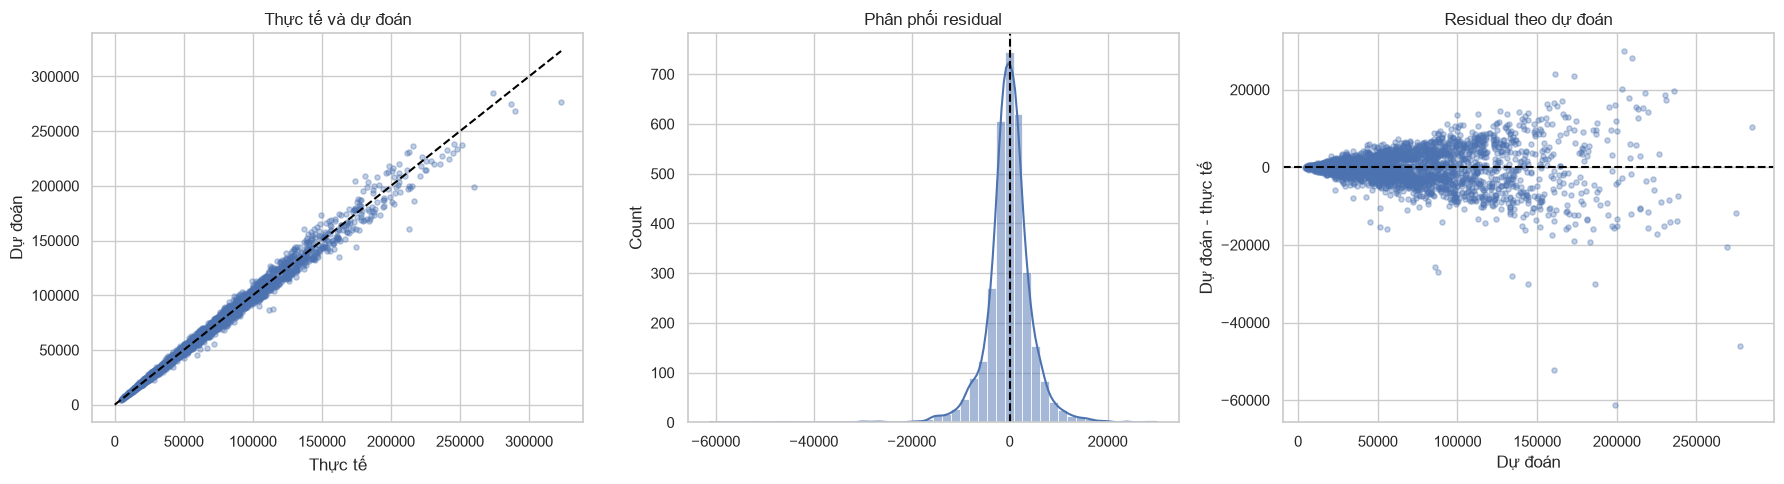

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(y_test, test_pred, alpha=.35, s=14)
limit = max(y_test.max(), test_pred.max())
axes[0].plot([0, limit], [0, limit], "--", color="black")
axes[0].set(title="Thực tế và dự đoán", xlabel="Thực tế", ylabel="Dự đoán")

residual = test_pred - y_test.to_numpy()
sns.histplot(residual, bins=50, kde=True, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Phân phối residual")

axes[2].scatter(test_pred, residual, alpha=.35, s=14)
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set(title="Residual theo dự đoán", xlabel="Dự đoán", ylabel="Dự đoán - thực tế")
plt.tight_layout()
plt.show()

## 6. Lưu artifact và theo dõi thí nghiệm

In [11]:
import joblib
import mlflow
from datetime import datetime, timezone

artifact_dir = ROOT / "outputs" / "notebook_artifacts"
report_dir = ROOT / "outputs" / "reports"
artifact_dir.mkdir(parents=True, exist_ok=True)
report_dir.mkdir(parents=True, exist_ok=True)

reference = {}
for col in X_train_val.select_dtypes(include=np.number).columns:
    values = X_train_val[col].replace([np.inf, -np.inf], np.nan).dropna()
    reference[col] = {
        "p01": float(values.quantile(.01)), "p50": float(values.quantile(.50)),
        "p99": float(values.quantile(.99)), "mean": float(values.mean()),
    }

artifact = {
    "pipeline": final_pipeline,
    "model_name": best_name,
    "target": TARGET,
    "feature_columns": X_train_val.columns.tolist(),
    "metrics": {k: float(v) for k, v in test_metrics.items()},
    "calibration_abs_error_q90": calibration_q90,
    "manual_review_width_threshold": manual_review_width_threshold,
    "reference": reference,
    "created_at": datetime.now(timezone.utc).isoformat(),
    "scope": "positive_sanction_prequalified_applications",
}
joblib.dump(artifact, artifact_dir / "best_model.joblib")

predictions = test_df.copy()
predictions["raw_prediction"] = raw_test_pred
predictions["prediction"] = test_pred
predictions["residual"] = test_pred - predictions[TARGET]
predictions["absolute_error"] = predictions["residual"].abs()
predictions.to_csv(report_dir / "internal_test_predictions.csv", index=True, index_label="source_index")
comparison.to_csv(report_dir / "model_comparison.csv", index=False)

with open(report_dir / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump({"model": best_name, **artifact["metrics"]}, f, ensure_ascii=False, indent=2)

tracking_db = (ROOT / "outputs" / "mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{tracking_db.as_posix()}")
mlflow.set_experiment("lendscope-regression")
with mlflow.start_run(run_name=f"notebook-{best_name}"):
    mlflow.log_param("model", best_name)
    mlflow.log_param("population", artifact["scope"])
    mlflow.log_metrics({f"test_{k}": float(v) for k, v in test_metrics.items()})
    mlflow.log_artifact(str(report_dir / "model_comparison.csv"))
print(f"Đã lưu artifact: {(artifact_dir / 'best_model.joblib').relative_to(ROOT)}")

Đã lưu artifact: outputs\notebook_artifacts\best_model.joblib


## 7. Kết luận thực nghiệm

In [12]:
mae_gain = 1 - test_metrics["mae"] / rule70_test["mae"]
display(Markdown(f"""
### Kết luận

- Ba mô hình dẫn đầu validation được kiểm tra bằng 3-fold CV; mô hình có CV MAE tốt nhất và được chọn trước khi mở test là **{best_name}**.
- Trên test nội bộ khóa trước, MAE đạt **{test_metrics['mae']:,.0f} USD**, RMSE **{test_metrics['rmse']:,.0f} USD**, R² **{test_metrics['r2']:.4f}**.
- Tỷ lệ dự đoán nằm trong ±10% là **{test_metrics['within_10pct']:.1%}**, trong ±20% là **{test_metrics['within_20pct']:.1%}**.
- So với rule 70%, MAE cải thiện **{mae_gain:.1%}**. Đây mới là mức tăng có ý nghĩa vì rule 70% phản ánh policy thật trong dữ liệu.
- `mean_signed_error={test_metrics['mean_signed_error']:,.0f}` USD cho biết xu hướng lệch tổng thể; dấu dương là thiên về cấp cao hơn lịch sử, dấu âm là thấp hơn.
- Test ngoài không có nhãn nên không được dùng để công bố metrics.
"""))


### Kết luận

- Ba mô hình dẫn đầu validation được kiểm tra bằng 3-fold CV; mô hình có CV MAE tốt nhất và được chọn trước khi mở test là **RandomForest**.
- Trên test nội bộ khóa trước, MAE đạt **3,136 USD**, RMSE **4,789 USD**, R² **0.9886**.
- Tỷ lệ dự đoán nằm trong ±10% là **96.4%**, trong ±20% là **99.8%**.
- So với rule 70%, MAE cải thiện **19.7%**. Đây mới là mức tăng có ý nghĩa vì rule 70% phản ánh policy thật trong dữ liệu.
- `mean_signed_error=-121` USD cho biết xu hướng lệch tổng thể; dấu dương là thiên về cấp cao hơn lịch sử, dấu âm là thấp hơn.
- Test ngoài không có nhãn nên không được dùng để công bố metrics.
